### Handling Missing Values

Missing values are empty or unknown entries in a dataset. They can happen because of data entry mistakes, sensor problems, skipped answers, or values that were not recorded.

In this notebook, we will learn:
1. how to find missing values,
2. when it is okay to remove them,
3. common ways to fill them in,
4. and how the choice changes the data.

We will use the Titanic dataset so the examples stay simple and easy to follow.



## Missing Data Mechanisms

Understanding why data is missing is crucial for choosing the right imputation strategy.
There are three main mechanisms that explain how missing data occurs:

### 1. Missing Completely At Random (MCAR)

**Definition:** Missing data is completely independent of both observed and unobserved data.

**Characteristics:**
- The probability of a value being missing is the same for all observations
- Missing values are not related to the variable itself or any other variables
- Example: A sensor randomly fails to record data regardless of conditions

**Example in Titanic dataset:**
- Age values missing due to random data entry errors (not related to age, class, or survival)

**Impact:** 
- Least problematic for analysis
- Unbiased estimates when data is MCAR
- Simple methods like listwise deletion are acceptable

**Best practices:**
- Multiple imputation methods work well
- Mean/median imputation is reasonable
- Statistical tests remain valid

---

### 2. Missing At Random (MAR)

**Definition:** Missing data depends on observed variables, but not on the unobserved variable itself.

**Characteristics:**
- The probability of missingness depends on other observed variables
- After accounting for observed variables, missingness is random
- Example: Older passengers were less likely to report age, but age missingness doesn't depend on actual age values

**Example in Titanic dataset:**
- Embarked port might be missing more often for certain ticket classes
- But given the ticket class, missingness is random

**Impact:**
- More complex to handle than MCAR
- Simple deletion can introduce bias
- Need to account for relationships with other variables

**Best practices:**
- Use methods that consider relationships between variables
- KNN imputation (considers similar passengers)
- Iterative imputation (MICE) works well
- Multiple imputation methods are recommended

---

### 3. Missing Not At Random (MNAR)

**Definition:** Missing data depends on the unobserved values themselves.

**Characteristics:**
- The probability of missingness is related to the missing value
- Cannot be handled by just observing other variables
- Most problematic type of missingness
- Example: Wealthy passengers might not report their fare (high values are missing)

**Example in Titanic dataset:**
- Cabin information missing because poorer passengers were less likely to have assigned cabins
- Missing values are fundamentally different from observed values

**Impact:**
- Can introduce significant bias
- Standard imputation methods may not be appropriate
- Requires domain knowledge to address properly

**Best practices:**
- Domain expertise is essential
- Sensitivity analysis to test assumptions
- Consider whether to exclude affected variables
- Use methods that acknowledge the assumption about missingness mechanism
- May need to model the missing data mechanism explicitly

---

### Summary Table

| Mechanism | Depends On | Biased if Deleted? | Simple Imputation OK? | Recommended Method |
|-----------|-----------|-------------------|----------------------|-------------------|
| MCAR      | Nothing   | No                | Yes                  | Any method         |
| MAR       | Observed  | Yes               | Risky                | KNN, MICE, MI      |
| MNAR      | Unobserved| Yes               | No                   | Domain knowledge + sensitivity analysis |


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)


In [2]:
df = sns.load_dataset('titanic')


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


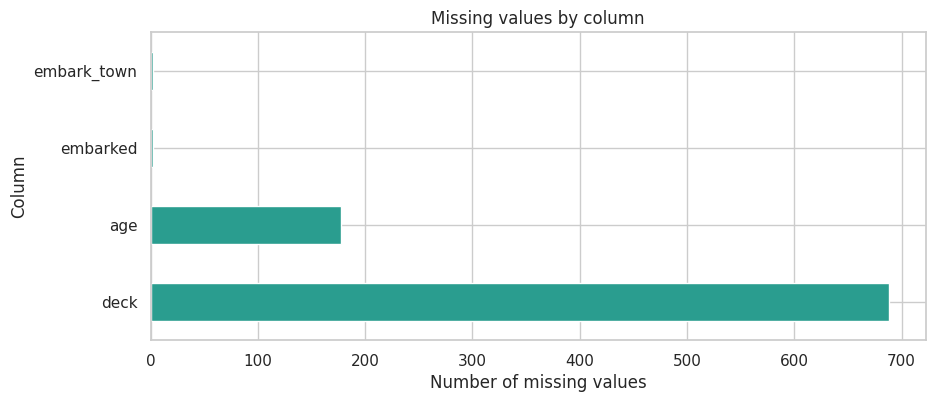

In [4]:
# Count missing values in each column and show them as a chart
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_counts

missing_counts.plot(kind="barh", color="#2a9d8f")
plt.title("Missing values by column")
plt.xlabel("Number of missing values")
plt.ylabel("Column")
plt.show()


In [5]:
## Delete the rows or data points to handle missing values 
df.shape


(891, 15)

In [6]:
# Dropping rows with any missing value removes a lot of data
rows_before = len(df)
rows_after = len(df.dropna())

print(f"Rows before dropping missing values: {rows_before}")
print(f"Rows after dropping missing values: {rows_after}")
print(f"Rows kept: {rows_after / rows_before:.1%}")


Rows before dropping missing values: 891
Rows after dropping missing values: 182
Rows kept: 20.4%


In [7]:
# Dropping columns with any missing value keeps only fully complete columns
columns_after_drop = df.dropna(axis=1).columns.tolist()
columns_after_drop


['survived',
 'pclass',
 'sex',
 'sibsp',
 'parch',
 'fare',
 'class',
 'who',
 'adult_male',
 'alive',
 'alone']

## 1. Mean value imputation

Use the mean for numerical columns when the data is fairly symmetric and does not have strong outliers.


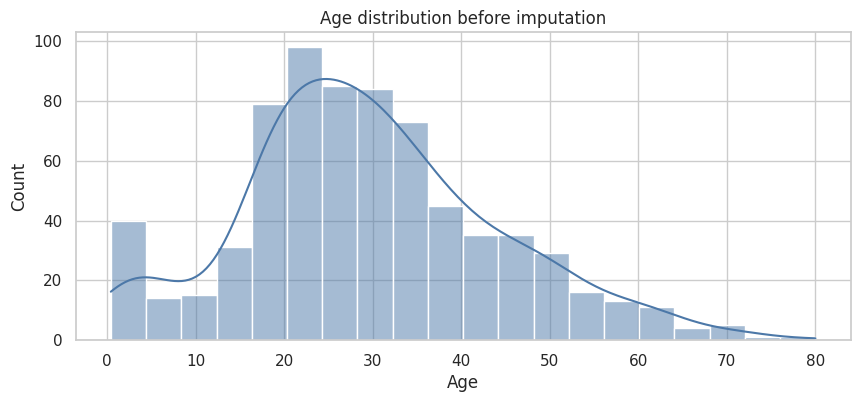

In [8]:
# Age has a few missing values, so we first look at its shape
sns.histplot(df["age"], kde=True, color="#4c78a8")
plt.title("Age distribution before imputation")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [9]:
mean_age = df["age"].mean()
df["age_mean"] = df["age"].fillna(mean_age)
df[["age", "age_mean"]].head(10)


,age,age_mean
0,22.0,22.000000
1,38.0,38.000000
2,26.0,26.000000
3,35.0,35.000000
4,35.0,35.000000
5,NaN,29.699118
6,54.0,54.000000
7,2.0,2.000000
8,27.0,27.000000
9,14.0,14.000000


In [10]:
df[['age_mean','age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


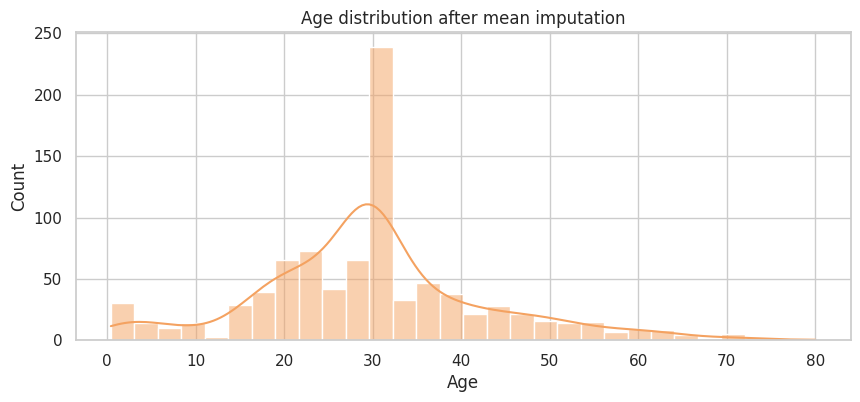

In [11]:
sns.histplot(df["age_mean"], kde=True, color="#f4a261")
plt.title("Age distribution after mean imputation")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Mean imputation works best when the distribution is roughly symmetric.


## 2. Median value imputation

Use the median for numerical columns when the data is skewed or contains outliers. The median is less affected by extreme values.


In [12]:
median_age = df["age"].median()
df["age_median"] = df["age"].fillna(median_age)
df[["age", "age_median"]].head(10)


,age,age_median
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
5,NaN,28.0
6,54.0,54.0
7,2.0,2.0
8,27.0,27.0
9,14.0,14.0


In [13]:
df[['age','age_median','age_mean']]

,age,age_median,age_mean
0,22.0,22.0,22.000000
1,38.0,38.0,38.000000
2,26.0,26.0,26.000000
3,35.0,35.0,35.000000
4,35.0,35.0,35.000000
...,...,...,...
886,27.0,27.0,27.000000
887,19.0,19.0,19.000000
888,NaN,28.0,29.699118
889,26.0,26.0,26.000000


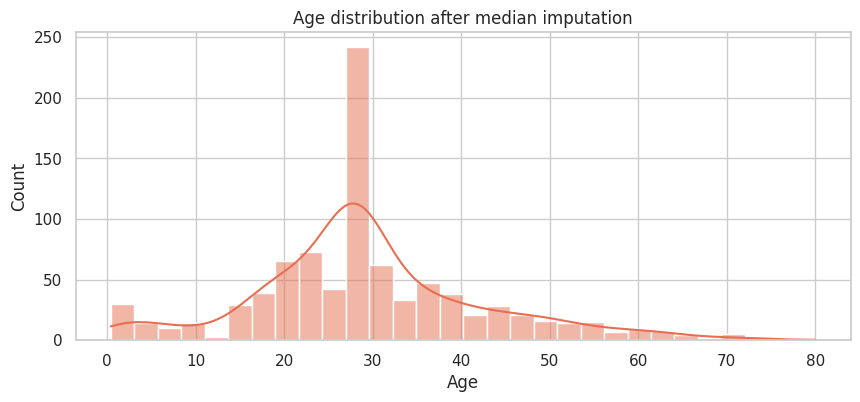

In [14]:
sns.histplot(df["age_median"], kde=True, color="#e76f51")
plt.title("Age distribution after median imputation")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### 3. Mode value imputation

Mode imputation is useful for categorical columns. We replace missing values with the most common category.


In [15]:
df[df["embarked"].isna()][["embarked", "embark_town"]]


,embarked,embark_town
61,NaN,NaN
829,NaN,NaN


In [16]:
df["embarked"].value_counts(dropna=False)


embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [17]:
df['embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [18]:
mode_value = df["embarked"].dropna().mode()[0]
mode_value


'S'

In [19]:
df["embarked_mode"] = df["embarked"].fillna(mode_value)
df[["embarked", "embarked_mode"]].head(10)


,embarked,embarked_mode
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
5,Q,Q
6,S,S
7,S,S
8,S,S
9,C,C


In [20]:
df["embarked_mode"].isna().sum()


np.int64(0)

In [21]:
# The new column has no missing values left
"Missing values left in embarked_mode: {}".format(df["embarked_mode"].isna().sum())


'Missing values left in embarked_mode: 0'

## From-scratch implementation: manual imputation vs `SimpleImputer`

Mean/median imputation is a single number: compute one statistic from the observed values,
fill every missing entry with it. That statistic is easy to compute by hand with plain NumPy —
no library is doing anything clever underneath `SimpleImputer`. The cell below implements both
by hand (`np.nanmean` / `np.nanmedian` plus a `where`) and compares the result element-for-element
against `sklearn.impute.SimpleImputer` fit on the same column.

In [22]:
def manual_mean_impute(series: pd.Series):
    """Fill NaNs with the column mean, computed by hand from the observed values."""
    values = series.to_numpy(dtype=float)
    mean_val = np.nanmean(values)          # mean over non-NaN entries only
    filled = np.where(np.isnan(values), mean_val, values)
    return filled, mean_val


def manual_median_impute(series: pd.Series):
    """Fill NaNs with the column median, computed by hand from the observed values."""
    values = series.to_numpy(dtype=float)
    median_val = np.nanmedian(values)
    filled = np.where(np.isnan(values), median_val, values)
    return filled, median_val


manual_mean_vals, manual_mean_stat = manual_mean_impute(df["age"])
manual_median_vals, manual_median_stat = manual_median_impute(df["age"])

sk_mean_imputer = SimpleImputer(strategy="mean")
sk_mean_vals = sk_mean_imputer.fit_transform(df[["age"]]).ravel()

sk_median_imputer = SimpleImputer(strategy="median")
sk_median_vals = sk_median_imputer.fit_transform(df[["age"]]).ravel()

print("manual mean statistic:  ", manual_mean_stat, " | sklearn mean statistic:  ", sk_mean_imputer.statistics_[0])
print("manual median statistic:", manual_median_stat, " | sklearn median statistic:", sk_median_imputer.statistics_[0])
print("manual vs sklearn MEAN imputed values match:  ", np.allclose(manual_mean_vals, sk_mean_vals))
print("manual vs sklearn MEDIAN imputed values match:", np.allclose(manual_median_vals, sk_median_vals))


manual mean statistic:   29.69911764705882  | sklearn mean statistic:   29.69911764705882
manual median statistic: 28.0  | sklearn median statistic: 28.0
manual vs sklearn MEAN imputed values match:   True
manual vs sklearn MEDIAN imputed values match: True


## Beyond a single statistic: KNN imputation

Mean/median imputation fills every missing entry with the *same* number, regardless of what the
rest of that row looks like — it ignores the fact that a missing `age` for a first-class passenger
and a missing `age` for a third-class passenger probably come from different underlying
distributions. This is exactly the MAR case from the taxonomy above: missingness that depends on
*other observed columns*.

`sklearn.impute.KNNImputer` fixes this by filling a missing value with the (distance-weighted)
average of that same feature among the row's **K nearest neighbors** in the other, non-missing
feature columns — instead of one global number, each row gets a locally-appropriate estimate. This
is precisely the same "find the K closest points and average their values" idea covered in full,
from first principles (distance metrics, the bias/variance role of $K$, and why features must be
scaled first) in `../../05-machine-learning/09-knn/notes.md` — KNN imputation is that exact
algorithm, applied to fill in a missing feature value instead of predicting a target.

In [23]:
knn_features = df[["pclass", "sibsp", "parch", "fare", "age"]].copy()

knn_imputer = KNNImputer(n_neighbors=5)
knn_imputed = knn_imputer.fit_transform(knn_features)
knn_imputed_age = pd.Series(knn_imputed[:, -1], index=df.index)

comparison = pd.DataFrame({
    "original_age": df["age"],
    "global_mean_imputed": manual_mean_vals,
    "knn_imputed": knn_imputed_age,
}).loc[df["age"].isna()]

comparison.head(10)


,original_age,global_mean_imputed,knn_imputed
5,NaN,29.699118,24.800
17,NaN,29.699118,34.600
19,NaN,29.699118,30.500
26,NaN,29.699118,30.500
28,NaN,29.699118,30.400
29,NaN,29.699118,30.200
31,NaN,29.699118,21.584
32,NaN,29.699118,30.700
36,NaN,29.699118,23.400
42,NaN,29.699118,30.200


## Failure mode: imputing before the train/test split (data leakage)

A common, easy-to-miss bug: compute the imputation statistic (mean, median, or a fitted
`KNNImputer`) on the **whole** dataset, *then* split into train/test. Whatever value fills a
missing entry in the test set was computed using information from the test set itself (its own
observed rows contributed to that mean) — the model implicitly "saw" a summary of the test
distribution before it was ever evaluated on it. The correct order is: split first, fit the
imputer on the training fold only, then apply that already-fitted imputer to the test fold. The
first cell below measures the direct, concrete effect on the actual imputed values and on
downstream accuracy for this dataset; the second amplifies the same bug (smaller sample, higher
missing fraction) to show the effect grows once the imputation statistic is a much noisier
estimate of the population value.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

leak_df = df[["survived", "pclass", "sex", "age", "fare"]].copy()
leak_df["sex"] = (leak_df["sex"] == "male").astype(int)


def leaky_pipeline(data: pd.DataFrame, seed: int):
    d = data.copy()
    global_mean = d["age"].mean()                     # LEAK: statistic uses every row, incl. future test rows
    d["age"] = d["age"].fillna(global_mean)
    X, y = d[["pclass", "sex", "age", "fare"]], d["survived"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test)), global_mean


def correct_pipeline(data: pd.DataFrame, seed: int):
    d = data.copy()
    X, y = d[["pclass", "sex", "age", "fare"]], d["survived"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    train_mean = X_train["age"].mean()                 # fit statistic on TRAIN ONLY
    X_train = X_train.copy(); X_test = X_test.copy()
    X_train["age"] = X_train["age"].fillna(train_mean)
    X_test["age"] = X_test["age"].fillna(train_mean)   # apply the already-fitted statistic to test
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test)), train_mean


leaky_accs, correct_accs, global_means, train_means = [], [], [], []
for seed in range(100):
    la, gm = leaky_pipeline(leak_df, seed)
    ca, tm = correct_pipeline(leak_df, seed)
    leaky_accs.append(la); correct_accs.append(ca)
    global_means.append(gm); train_means.append(tm)

print(f"Global mean age (whole dataset, what the leaky pipeline uses): {df['age'].mean():.4f}")
print(f"Example train-only mean age (seed=0): {train_means[0]:.4f}  (global mean differs by {global_means[0]-train_means[0]:+.4f})")
print()
print(f"Leaky pipeline   mean test accuracy over 100 splits: {np.mean(leaky_accs):.4f}")
print(f"Correct pipeline mean test accuracy over 100 splits: {np.mean(correct_accs):.4f}")
print(f"Mean difference (leaky - correct): {np.mean(leaky_accs) - np.mean(correct_accs):+.4f}")


Global mean age (whole dataset, what the leaky pipeline uses): 29.6991
Example train-only mean age (seed=0): 29.9153  (global mean differs by -0.2162)

Leaky pipeline   mean test accuracy over 100 splits: 0.7909
Correct pipeline mean test accuracy over 100 splits: 0.7907
Mean difference (leaky - correct): +0.0002


In [25]:
# The Titanic dataset's imputation statistic barely differs between "global" and "train-only" (891
# rows, ~20% missing), so the downstream metric gap is tiny. Amplify the exact same bug with a
# smaller sample and a higher missing fraction, where the imputation statistic is a much noisier
# estimate of the true population mean, to see the effect grow.

def make_synthetic(n: int, seed: int):
    rng = np.random.default_rng(seed)
    feature = rng.normal(40, 15, size=n)
    noise = rng.normal(0, 8, size=n)
    target = (feature + noise > 40).astype(int)
    missing_mask = rng.random(n) < 0.6
    observed = feature.copy()
    observed[missing_mask] = np.nan
    return observed, target


def synthetic_leaky_acc(observed, target, seed):
    global_mean = np.nanmean(observed)
    X = np.where(np.isnan(observed), global_mean, observed).reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.5, random_state=seed)
    model = LogisticRegression().fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))


def synthetic_correct_acc(observed, target, seed):
    X = observed.reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.5, random_state=seed)
    train_mean = np.nanmean(X_train)
    X_train = np.where(np.isnan(X_train), train_mean, X_train).reshape(-1, 1)
    X_test = np.where(np.isnan(X_test), train_mean, X_test).reshape(-1, 1)
    model = LogisticRegression().fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))


syn_leaky, syn_correct = [], []
for trial in range(300):
    observed, target = make_synthetic(n=40, seed=trial)
    syn_leaky.append(synthetic_leaky_acc(observed, target, trial))
    syn_correct.append(synthetic_correct_acc(observed, target, trial))

wins_leaky = sum(a > b for a, b in zip(syn_leaky, syn_correct))
wins_correct = sum(a < b for a, b in zip(syn_leaky, syn_correct))
print(f"n=40, 60% missing, 300 trials (test_size=0.5):")
print(f"  Leaky pipeline   mean test accuracy: {np.mean(syn_leaky):.4f}")
print(f"  Correct pipeline mean test accuracy: {np.mean(syn_correct):.4f}")
print(f"  Mean difference (leaky - correct):   {np.mean(syn_leaky) - np.mean(syn_correct):+.4f}")
print(f"  Trials where leaky > correct: {wins_leaky}/300   |   correct > leaky: {wins_correct}/300")


n=40, 60% missing, 300 trials (test_size=0.5):
  Leaky pipeline   mean test accuracy: 0.6325
  Correct pipeline mean test accuracy: 0.6232
  Mean difference (leaky - correct):   +0.0093
  Trials where leaky > correct: 73/300   |   correct > leaky: 39/300
